In [1]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

In [3]:
df_bow = pd.read_csv("dados/df_final_bow.csv")
df_tfidf = pd.read_csv("dados/df_final_tfidf.csv")

print(f"BoW:    {df_bow.shape}")
print(f"TF-IDF: {df_tfidf.shape}")
df_bow.head()

C:\Users\mjlia\AppData\Local\Temp\ipykernel_19544\1930425656.py:1: DtypeWarning: Columns (0: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bow = pd.read_csv("dados/df_final_bow.csv")
C:\Users\mjlia\AppData\Local\Temp\ipykernel_19544\1930425656.py:2: DtypeWarning: Columns (0: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tfidf = pd.read_csv("dados/df_final_tfidf.csv")


BoW:    (333, 17206)
TF-IDF: (333, 18608)


,Unnamed: 0,data,tags,titulo,url,texto,bow_aab,bow_aabertura,bow_aadk,bow_aalemanhacompleta,...,bow_zoagaharlley,bow_zona,bow_zonas,bow_zone,bow_zones,bow_zoologicos,bow_zotto,bow_zuerlein,bow_zvi,palavras_unicas
0,0,Sem data,NaN,Tati Weston-Webb vence número um do mundo no s...,https://exame.com/esporte/tati-weston-webb-ven...,Surfe feminino: veja quem se classificou para ...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,174
1,1,Sem data,NaN,Olimpíadas de Inverno: hoje tem Brasil no Bobs...,https://exame.com/esporte/olimpiadas-de-invern...,Edson Luques Bindilatti e Luis Bacca Gonçalves...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,171
2,2,Sem data,NaN,Paris 2024: Futebol olímpico terminará com a f...,https://exame.com/esporte/paris-2024-futebol-o...,Calendários das partidas das competições foram...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,200
3,3,Sem data,NaN,"Após bater em duas barreiras, Alison dos Santo...",https://exame.com/esporte/apos-bater-em-duas-b...,Alison dos Santos: atleta é medalhista olímpic...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,264
4,4,Sem data,NaN,Da roça para Paris: a história inspiradora do ...,https://exame.com/carreira/da-roca-para-paris-...,"Maranhão, atleta olímpico de arremedo de peso:...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,487


In [4]:
colunas_bow = [c for c in df_bow.columns if c.startswith("bow_")]
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]

X_bow = df_bow[colunas_bow].values
X_tfidf = df_tfidf[colunas_tfidf].values

titulos = df_bow["titulo"].tolist()

print(f"X_bow:   {X_bow.shape}")
print(f"X_tfidf: {X_tfidf.shape}")

X_bow:   (333, 17199)
X_tfidf: (333, 18602)


In [23]:
perplexity = 10
random_state = 42

tsne_bow = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="random")
embed_bow = tsne_bow.fit_transform(X_bow)

tsne_tfidf = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="random")
embed_tfidf = tsne_tfidf.fit_transform(X_tfidf)

print("embed_bow:  ", embed_bow.shape)
print("embed_tfidf:", embed_tfidf.shape)

embed_bow:   (333, 2)
embed_tfidf: (333, 2)


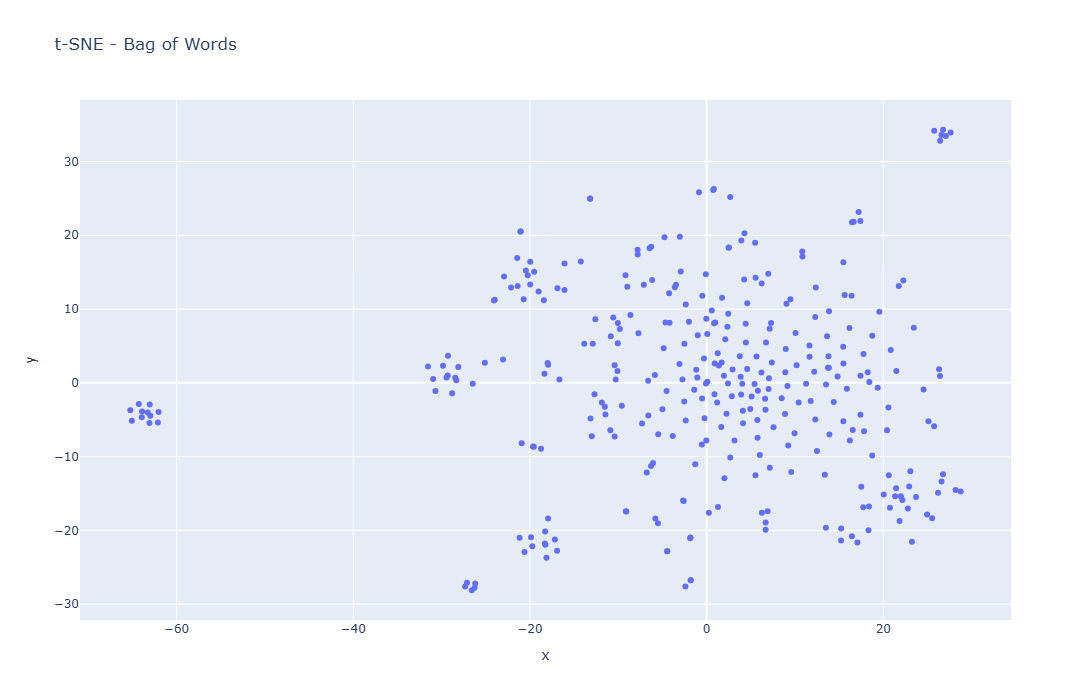

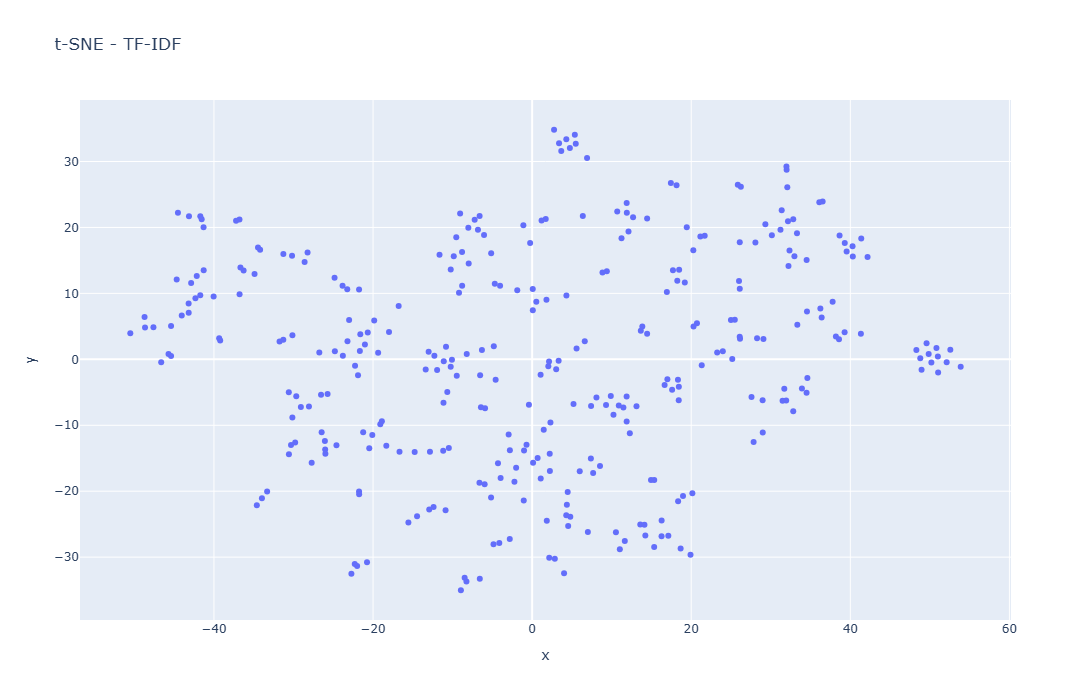

In [24]:
def plotar(embed, nome):
    df_plot = pd.DataFrame({
        "x": embed[:, 0],
        "y": embed[:, 1],
        "indice": df_bow.index,
        "titulo": df_bow["titulo"],
        "data": df_bow["data"],
    })
    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        hover_data={"indice": True, "titulo": True, "data": False, "x": False, "y": False},
        title=f"t-SNE - {nome}",
        width=700,
        height=700,
    )
    fig.write_html(nome+".html")
    fig.show()


plotar(embed_bow, "Bag of Words")
plotar(embed_tfidf, "TF-IDF")